<a href="https://colab.research.google.com/github/imchrisrueda/extML/blob/main/k_brazos/banditSoftmax.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Bandido de k-brazos — Softmax

*Descripción:* Estudio comparativo de configuraciones del algoritmo **Softmax (función de Gibbs)** en el problema del bandido de k-brazos usando distribuciones **Normal**, **Bernoulli** y **Binomial**.

En este notebook se comparan tres temperaturas (`T=0.1`, `T=0.5`, `T=1.0`) y se analizan cuatro tipos de evidencias experimentales:

- Recompensa promedio por paso.
- Porcentaje de selección del brazo óptimo.
- Regret acumulado empírico.
- Estadísticas por brazo (selecciones y recompensa promedio estimada).


## Preparación del entorno

In [11]:
# Copiar el repositorio.

# En Google Colab (ejemplo):
# !git clone https://github.com/imchrisrueda/extML.git
# %cd /content/extML/k_brazos


In [12]:
# Importamos todas las clases y funciones

import sys
from pathlib import Path
from typing import List

import numpy as np

# Añadir directorios al path de Python 
sys.path.append('/content/eml_k_bandit')
sys.path.append('/content/eml_k_bandit/k_brazos')

cwd = Path.cwd()
for candidate in (cwd, cwd / 'k_brazos'):
    candidate_str = str(candidate)
    if candidate_str not in sys.path and candidate.exists():
        sys.path.append(candidate_str)

# Clases y funciones para Softmax y Bandits
from src.algorithms import Algorithm, Softmax
from src.arms import ArmNormal, ArmBinomial, ArmBernoulli, Bandit
from src.plotting import plot_average_rewards, plot_optimal_selections, plot_arm_statistics, plot_regret


## Experimento

La función `run_experiment(...)` implementa el bucle principal de simulación para una instancia de bandido y un conjunto de algoritmos. En cada ejecución (`run`) se reinicia el estado de los algoritmos, se simulan `steps` interacciones y se acumulan las métricas relevantes.

Las salidas del experimento son:

- `rewards`: recompensa promedio por paso y algoritmo.
- `optimal_selections`: proporción de veces que se selecciona el brazo óptimo en cada paso.
- `regrets`: regret acumulado empírico por algoritmo.
- `counts_accum` y `values_accum`: estadísticas agregadas por brazo para análisis posteriores.


In [13]:
def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):
    
    optimal_arm = bandit.optimal_arm  # Necesario para calcular el porcentaje de selecciones óptimas.

    rewards = np.zeros((len(algorithms), steps))  # Matriz para almacenar las recompensas promedio.
    
    optimal_selections = np.zeros((len(algorithms), steps))  # Matriz para almacenar selecciones óptimas (proporción).

    np.random.seed(seed)  # Asegurar reproducibilidad de resultados.

    # Matriz para Regret acumulado: cada fila corresponde a un algoritmo, cada columna a un paso temporal.
    regrets = np.zeros((len(algorithms), steps))  # Matriz para almacenar el regret acumulado.
    q = bandit.get_expected_value(optimal_arm)  # Recompensa esperada del brazo óptimo.

    # Se acumulan los conteos y valores para mostrar en el gráfico de estadísticas de los brazos al final del experimento
    counts_accum = np.zeros((len(algorithms), bandit.k))
    values_accum = np.zeros((len(algorithms), bandit.k))

    for _ in range(runs):
        current_bandit = Bandit(arms=bandit.arms)

        for algo in algorithms:
            algo.reset() # Reiniciar el estado del algoritmo para cada corrida

        total_regret = np.zeros(len(algorithms)) # Vector para acumular el regret total de cada algoritmo a lo largo de los pasos

        for step in range(steps):
            for idx, algo in enumerate(algorithms):
                chosen_arm = algo.select_arm() # El algoritmo selecciona un brazo basado en su política
                reward = current_bandit.pull_arm(chosen_arm) # Se obtiene la recompensa al jalar el brazo seleccionado
                algo.update(chosen_arm, reward) # Actualizar el algoritmo con la recompensa obtenida

                rewards[idx, step] += reward # Acumular la recompensa para calcular el promedio al final

                if chosen_arm == optimal_arm: 
                    optimal_selections[idx, step] += 1 # Contar selección óptima para calcular el porcentaje al final

                total_regret[idx] += (q - reward) # Actualizar el regret total acumulado 
                regrets[idx, step] += total_regret[idx] # Acumular el regret total para calcular el promedio al final

        for idx, algo in enumerate(algorithms):
            counts_accum[idx] += algo.counts
            values_accum[idx] += algo.values

    # Promediar los resultados acumulados por el número de corridas para obtener las métricas finales
    rewards /= runs
    optimal_selections /= runs
    regrets /= runs
    counts_accum /= runs
    values_accum /= runs

    return rewards, optimal_selections, regrets, counts_accum, values_accum


## Ejecución del experimento

Se ejecuta el estudio con los parámetros `k=10`, `steps=1000` y `runs=500`, usando una semilla fija (`seed=42`) para asegurar reproducibilidad. La comparación se realiza sobre tres tipos de bandido:

- **Normal** (`N(\mu, \sigma^2)` con `\sigma=1` en la implementación actual).
- **Bernoulli** (recompensas binarias `0/1`).
- **Binomial** (`n=10`).

En cada distribución se comparan tres configuraciones de Softmax:

- `T=0.1` (más explotadora).
- `T=0.5` (intermedia).
- `T=1.0` (más exploradora dentro del rango evaluado).

Se analiza cómo el parámetro `temperature` afecta al equilibrio exploración-explotación en función de la naturaleza de la distribución de recompensas.

In [14]:
# Parámetros del experimento y construcción de algoritmos Softmax

seed = 42
np.random.seed(seed)

k = 10
steps = 1000
runs = 500

def build_softmax_algorithms(k: int):
    return [
        Softmax(k=k, temperature=0.1),
        Softmax(k=k, temperature=0.5),
        Softmax(k=k, temperature=1.0),
    ]


In [15]:
# Crear bandidos (Normal, Bernoulli, Binomial) y ejecutar experimentos

bandit_normal = Bandit(arms=ArmNormal.generate_arms(k))
bandit_bernoulli = Bandit(arms=ArmBernoulli.generate_arms(k))
bandit_binomial = Bandit(arms=ArmBinomial.generate_arms(k, n=10))

algorithms_normal = build_softmax_algorithms(k)
algorithms_bernoulli = build_softmax_algorithms(k)
algorithms_binomial = build_softmax_algorithms(k)

rewards_normal, optimal_normal, regrets_normal, counts_normal, values_normal = run_experiment(bandit_normal, algorithms_normal, steps, runs)
rewards_bernoulli, optimal_bernoulli, regrets_bernoulli, counts_bernoulli, values_bernoulli = run_experiment(bandit_bernoulli, algorithms_bernoulli, steps, runs)
rewards_binomial, optimal_binomial, regrets_binomial, counts_binomial, values_binomial = run_experiment(bandit_binomial, algorithms_binomial, steps, runs)


### Brazo óptimo y separación respecto al segundo mejor brazo

- **Normal**: brazo óptimo índice `7` (8.º brazo en notación 1-based), con valor esperado `μ*=9.56`. El segundo mejor brazo tiene `μ=8.80` (gap ≈ `0.76`).
- **Bernoulli**: brazo óptimo índice `0`, con probabilidad de éxito `p*=0.96`. El segundo mejor brazo tiene `p=0.83` (gap ≈ `0.13`).
- **Binomial** (`n=10`): brazo óptimo índice `2`, con valor esperado `E[X]=7.8`. El segundo mejor brazo tiene `E[X]=6.1` (gap ≈ `1.7`).

Estas diferencias son importantes para interpretar los resultados: el valor de `temperature` regula cuánto tiempo el algoritmo mantiene exploración estocástica sobre los valores `Q(a)` estimados.

Función auxiliar `build_arm_stats` para generar la estructura de datos necesaria para `plot_arm_statistics`. Esta función resume, para cada algoritmo y cada brazo:

- número promedio de selecciones (`selected`),
- recompensa media estimada (`avg_reward`),
- e indicador de si el brazo es óptimo (`is_optimal`).


In [16]:
# Construir estadísticas por brazo

def build_arm_stats(bandit, counts, values, algorithm_labels):
    optimal_arm = bandit.optimal_arm # Óptimo brazo para marcarlo en las estadísticas
    arm_stats = []

    for algo_idx in range(len(algorithm_labels)): # Iterar sobre cada algoritmo para construir sus estadísticas por brazo
        stats = {}
        for arm_idx in range(bandit.k):
            stats[arm_idx] = {
                'selected': counts[algo_idx][arm_idx],
                'avg_reward': values[algo_idx][arm_idx],
                'is_optimal': (arm_idx == optimal_arm),
            }
        arm_stats.append(stats)

    return arm_stats

# Construir estadísticas por brazo para cada tipo de bandido y algoritmo
arm_stats_normal = build_arm_stats(bandit_normal, counts_normal, values_normal, algorithms_normal)
arm_stats_bernoulli = build_arm_stats(bandit_bernoulli, counts_bernoulli, values_bernoulli, algorithms_bernoulli)
arm_stats_binomial = build_arm_stats(bandit_binomial, counts_binomial, values_binomial, algorithms_binomial)

## Visualización de los resultados

A continuación se presentan las gráficas del estudio (recompensa promedio, selección óptima y regret acumulado) junto con el análisis por brazo.

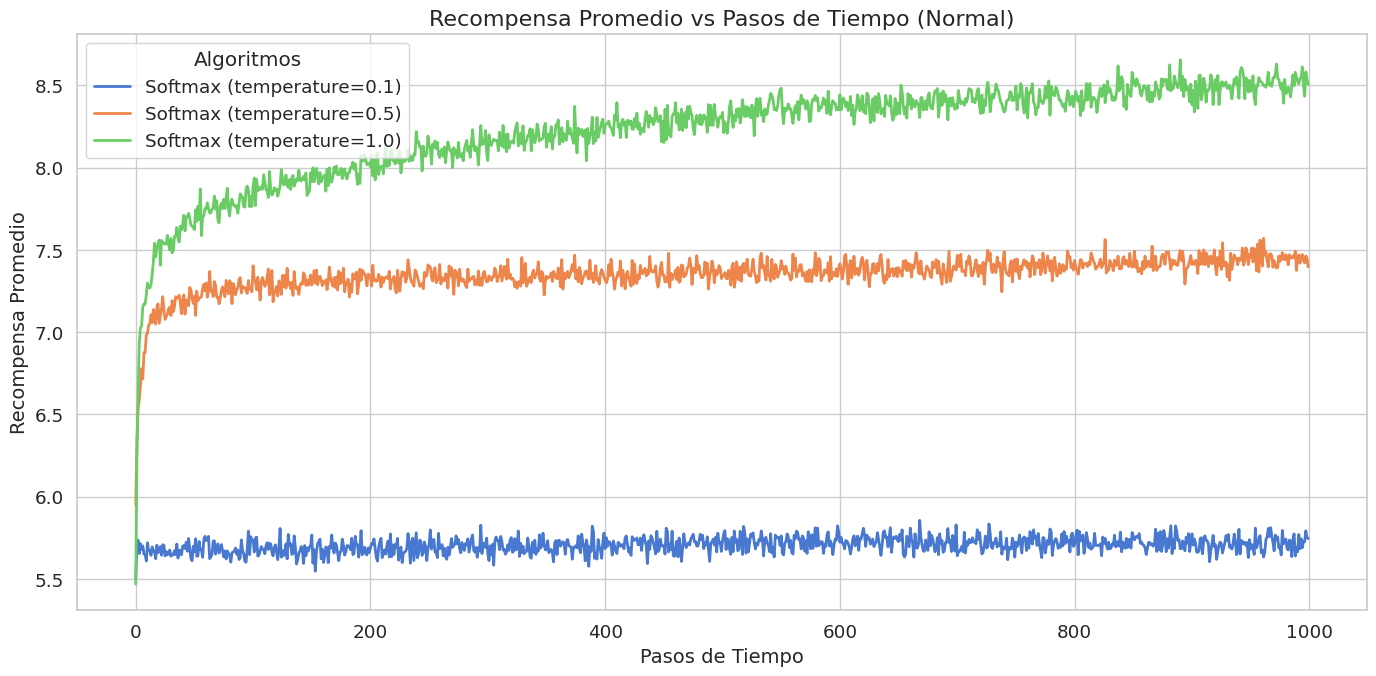

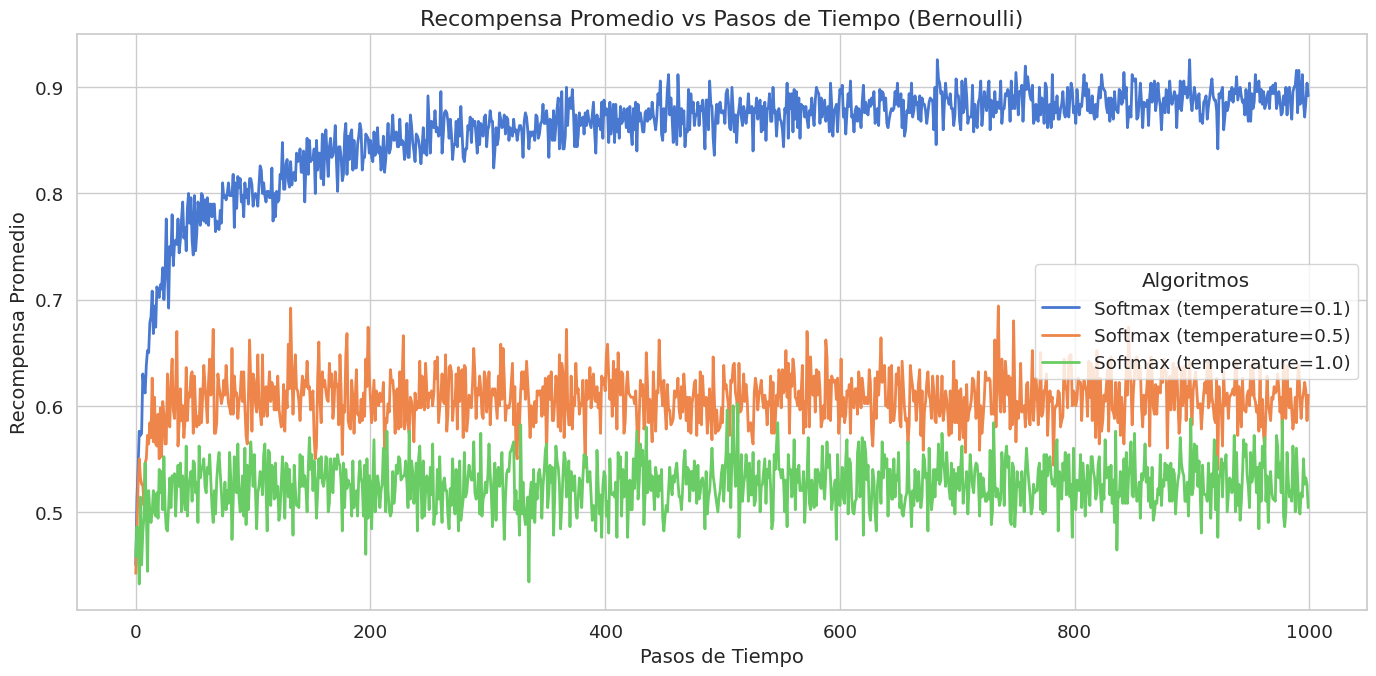

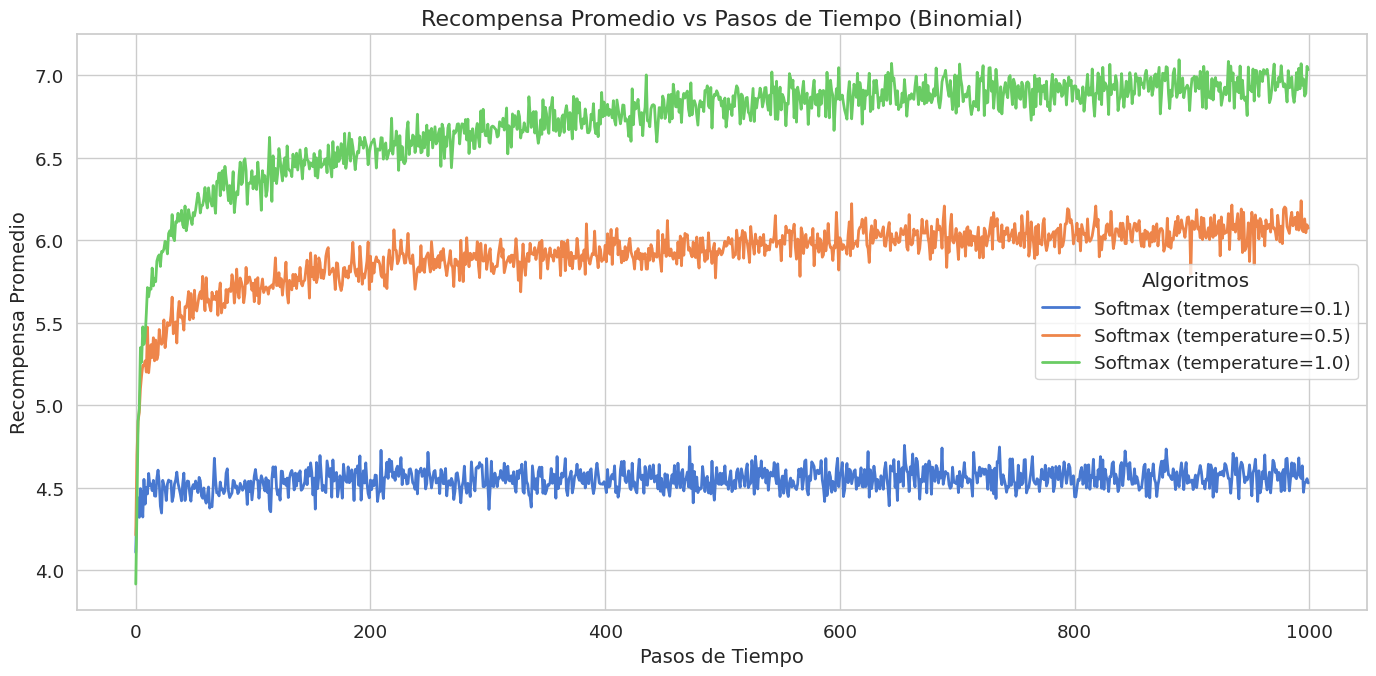

In [17]:
# Graficar recompensas promedio
plot_average_rewards(steps, rewards_normal, algorithms_normal, 'Normal')
plot_average_rewards(steps, rewards_bernoulli, algorithms_bernoulli, 'Bernoulli')
plot_average_rewards(steps, rewards_binomial, algorithms_binomial, 'Binomial')


### Recompensa promedio

Las curvas de **Recompensa Promedio vs Pasos de Tiempo** muestran el rendimiento instantáneo medio de cada configuración de `Softmax` a lo largo del horizonte temporal. Para resumir el comportamiento al final del aprendizaje, se reporta también la **media de recompensa en los últimos 100 pasos** (`t=901..1000`).

#### Resumen cuantitativo (promedio últimos 100 pasos)

| Distribución | `T=0.1` | `T=0.5` | `T=1.0` | Mejor temperatura |
|---|---:|---:|---:|---|
| Normal | 5.714 | 7.442 | **8.501** | `T=1.0` |
| Bernoulli | **0.889** | 0.605 | 0.529 | `T=0.1` |
| Binomial | 4.573 | 6.078 | **6.944** | `T=1.0` |

- **Normal** y **Binomial**: `T=1.0` obtiene la mejor recompensa promedio sostenida. Esto sugiere que una política más exploradora evita fijarse demasiado pronto en brazos subóptimos cuando las estimaciones `Q(a)` aún son inestables.
- **Bernoulli**: `T=0.1` supera claramente al resto. En esta instancia, el brazo óptimo (`p*=0.96`) es muy rentable, y mantener alta aleatoriedad (temperaturas mayores) perjudica la recompensa promedio por exceso de exploración.
- Las magnitudes absolutas de recompensa **no son directamente comparables entre distribuciones** debido a sus distintas escalas de recompensa.


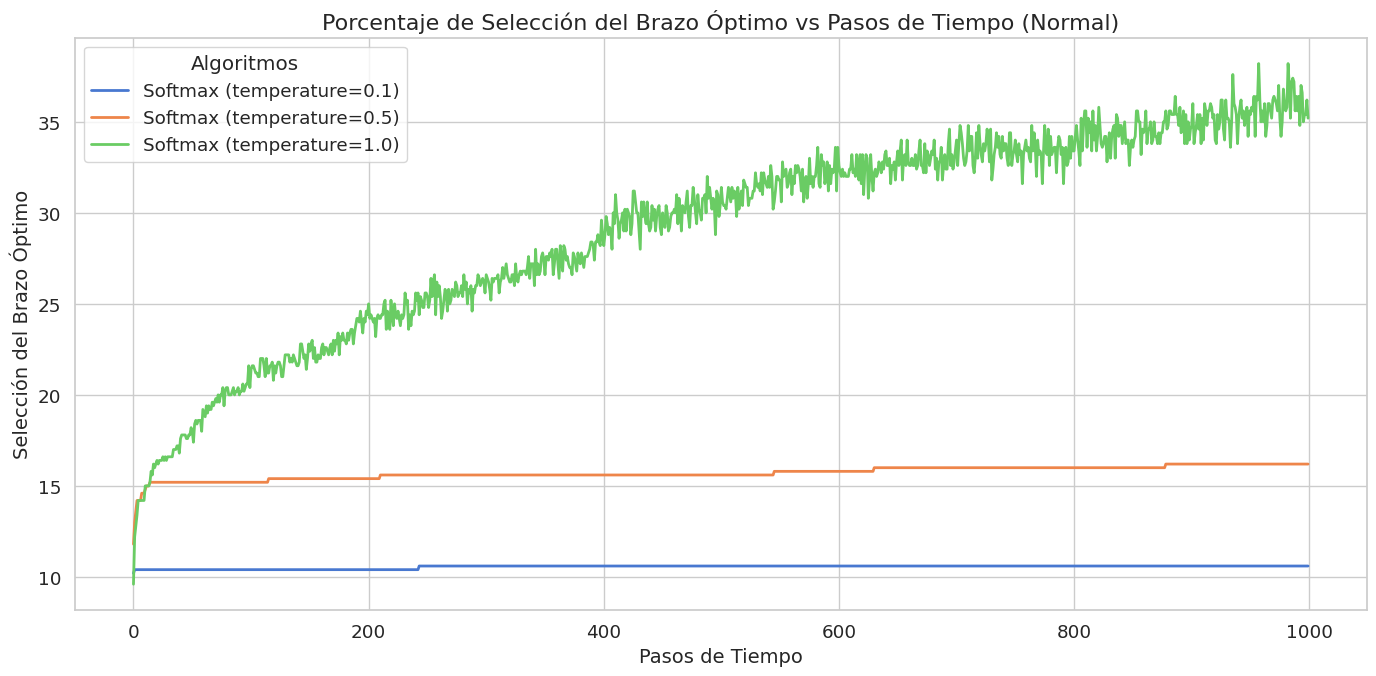

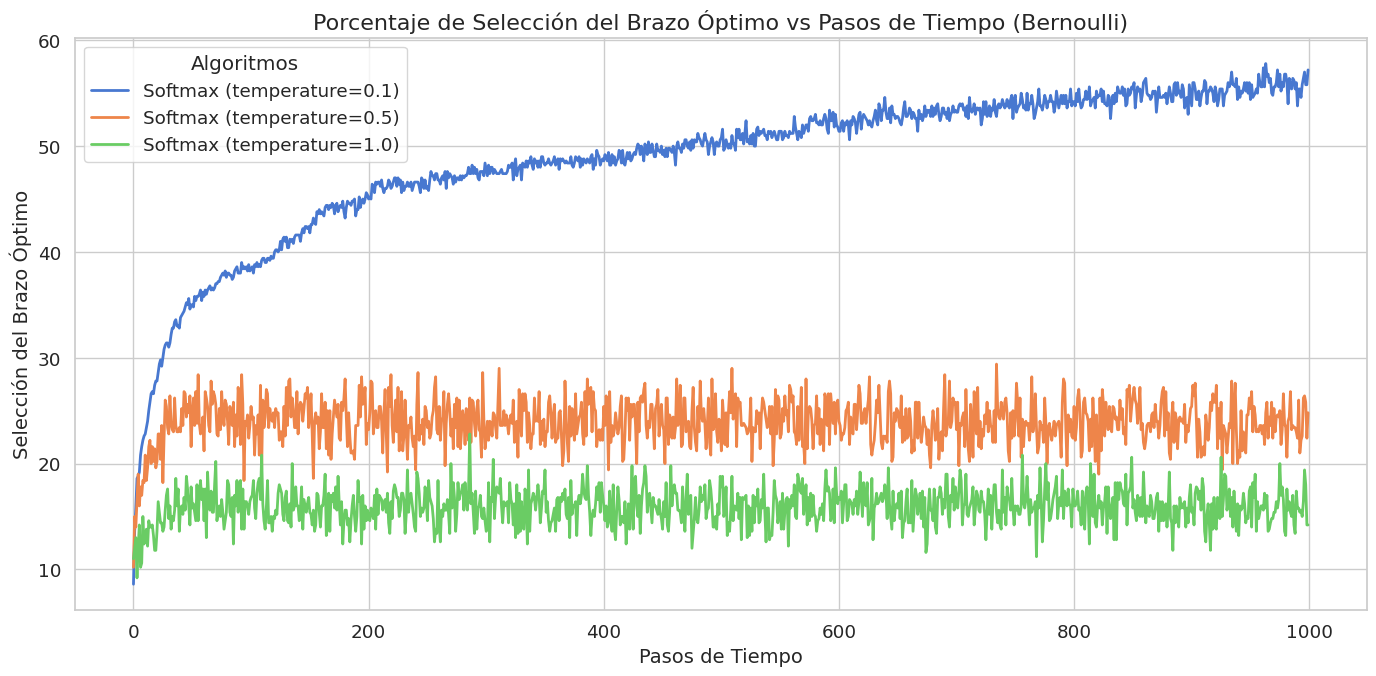

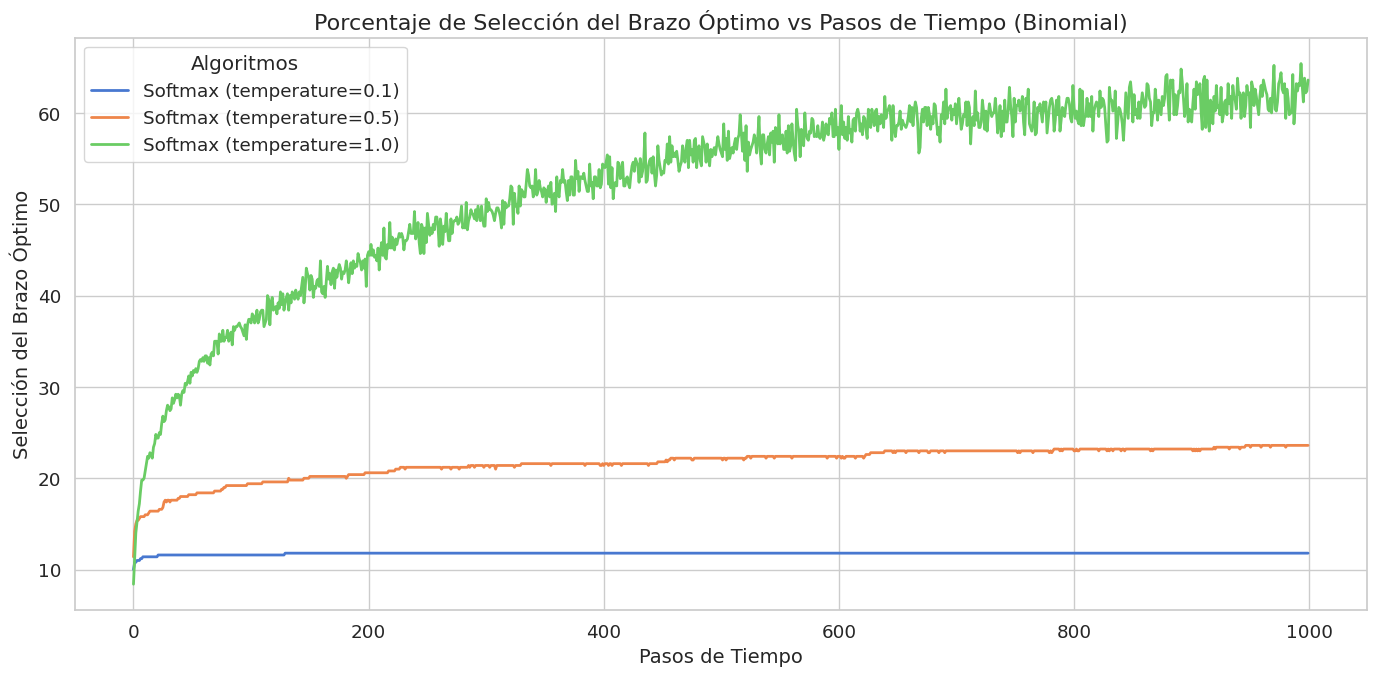

In [18]:
# Graficar porcentaje de selección del brazo óptimo

plot_optimal_selections(steps, optimal_normal, algorithms_normal, 'Normal')
plot_optimal_selections(steps, optimal_bernoulli, algorithms_bernoulli, 'Bernoulli')
plot_optimal_selections(steps, optimal_binomial, algorithms_binomial, 'Binomial')


### Selección del brazo óptimo

La gráfica de **Porcentaje de Selección del Brazo Óptimo vs Pasos de Tiempo** permite medir la calidad de la política independientemente de la escala de la recompensa. Es una métrica especialmente útil para comparar distribuciones heterogéneas.

#### Resultado al final del horizonte (`t=1000`)

| Distribución | `T=0.1` | `T=0.5` | `T=1.0` | Mejor temperatura |
|---|---:|---:|---:|---|
| Normal | 10.6% | 16.2% | **35.2%** | `T=1.0` |
| Bernoulli | **57.2%** | 24.8% | 14.2% | `T=0.1` |
| Binomial | 11.8% | 23.6% | **63.6%** | `T=1.0` |

- En **Normal** y **Binomial**, una temperatura alta (`T=1.0`) aumenta significativamente la probabilidad de encontrar y explotar el brazo óptimo en el largo plazo.
- En **Bernoulli**, `T=0.1` selecciona el brazo óptimo más de la mitad de las veces al final del experimento, mientras que `T=1.0` mantiene una exploración excesiva y reduce la precisión de la política.
- La coherencia entre esta métrica y la recompensa promedio indica que las diferencias de rendimiento no se deben solo a la escala de la recompensa, sino a una distinta capacidad de identificación del brazo óptimo.


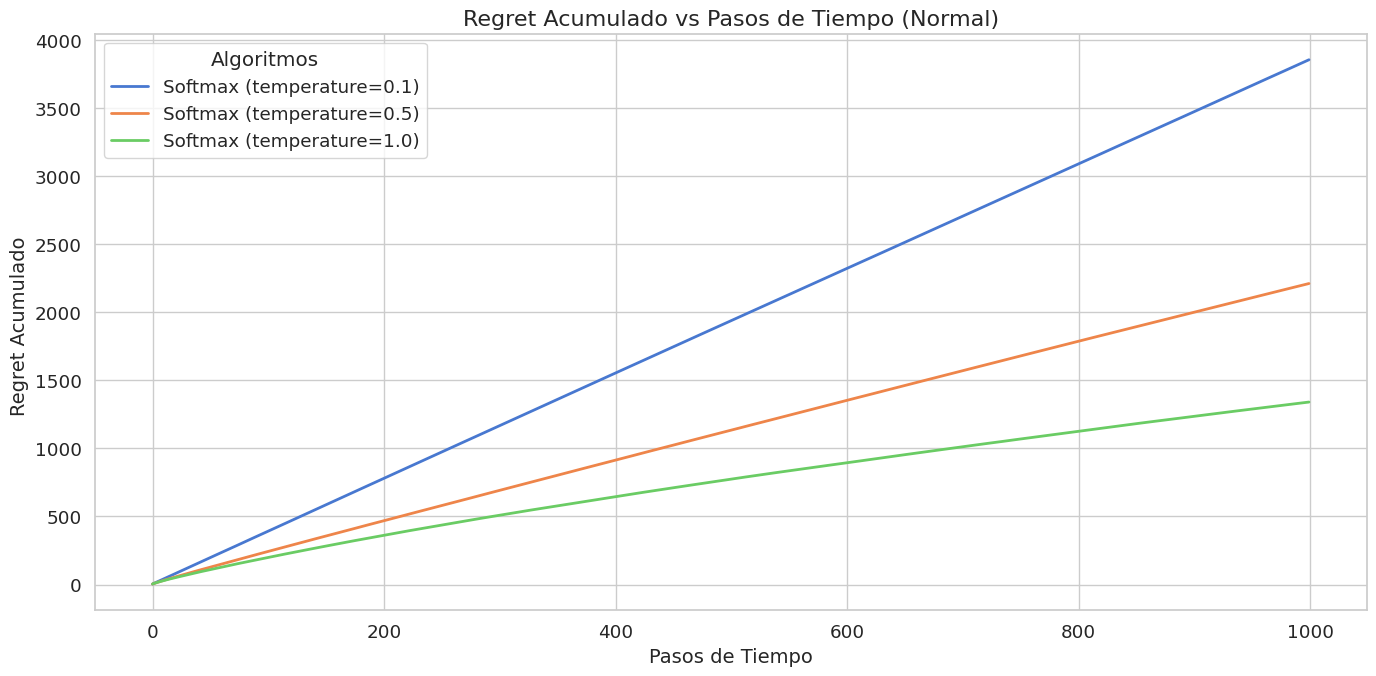

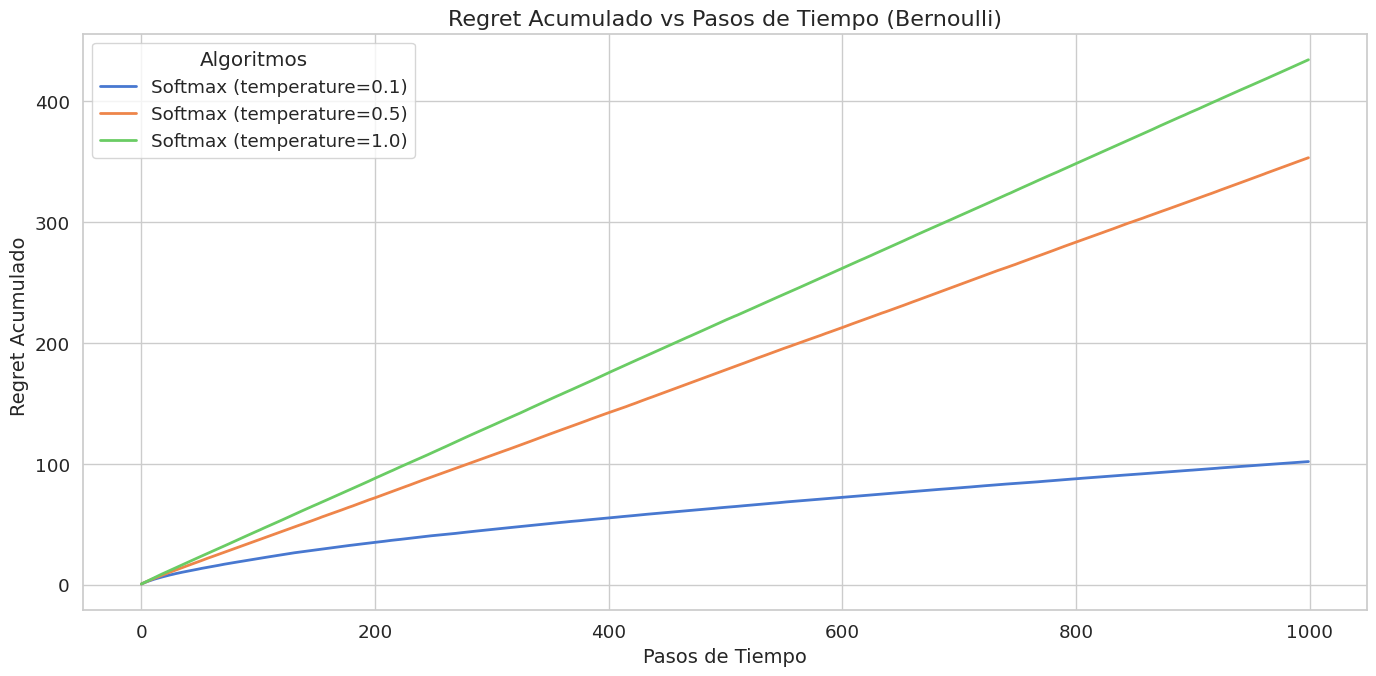

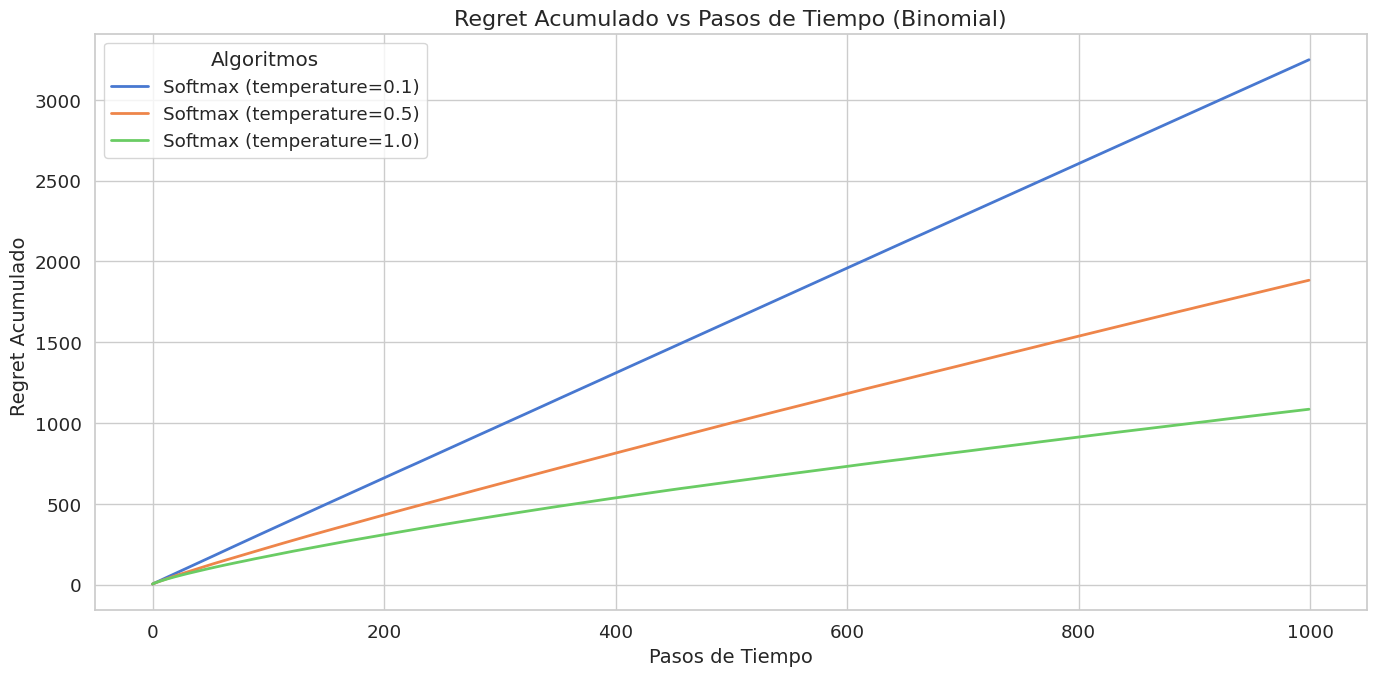

In [19]:
# Graficar regret acumulado

plot_regret(steps, regrets_normal, algorithms_normal, 'Normal')
plot_regret(steps, regrets_bernoulli, algorithms_bernoulli, 'Bernoulli')
plot_regret(steps, regrets_binomial, algorithms_binomial, 'Binomial')


### Regret acumulado

El **regret acumulado** usado en este notebook es empírico, en cada paso se acumula `q* - r_t`, donde `q*` es el valor esperado del brazo óptimo y `r_t` la recompensa observada. Esta definición incorpora la variabilidad estocástica de las recompensas, pero es adecuada para comparar algoritmos en la misma instancia de bandido.

#### Regret final en `t=1000` (menor es mejor)

| Distribución | `T=0.1` | `T=0.5` | `T=1.0` | Mejor temperatura |
|---|---:|---:|---:|---|
| Normal | 3854.32 | 2210.70 | **1340.15** | `T=1.0` |
| Bernoulli | **101.82** | 353.23 | 434.29 | `T=0.1` |
| Binomial | 3247.34 | 1883.08 | **1085.03** | `T=1.0` |

- El ranking por regret coincide con el ranking observado en recompensa promedio y selección óptima para las tres distribuciones.
- Este alineamiento refuerza la consistencia del estudio: la mejor configuración no solo obtiene recompensas mayores, sino que también reduce sistemáticamente la pérdida acumulada por no elegir siempre el brazo óptimo.
- En **Normal** y **Binomial**, la penalización por exploración insuficiente (`T=0.1`) es especialmente visible en el crecimiento del regret.


<Figure size 1400x700 with 0 Axes>

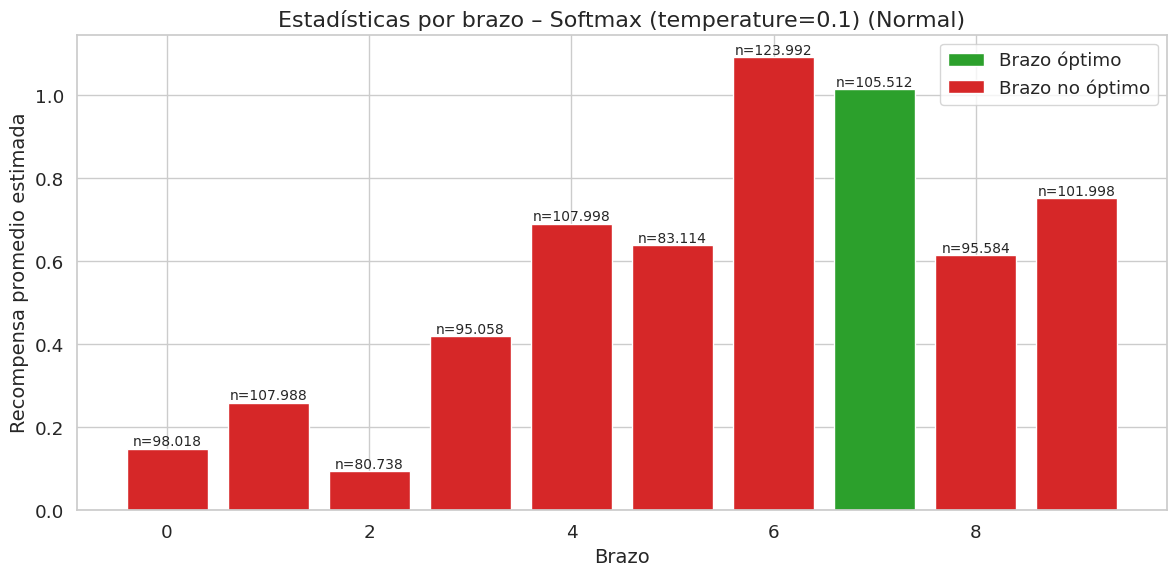

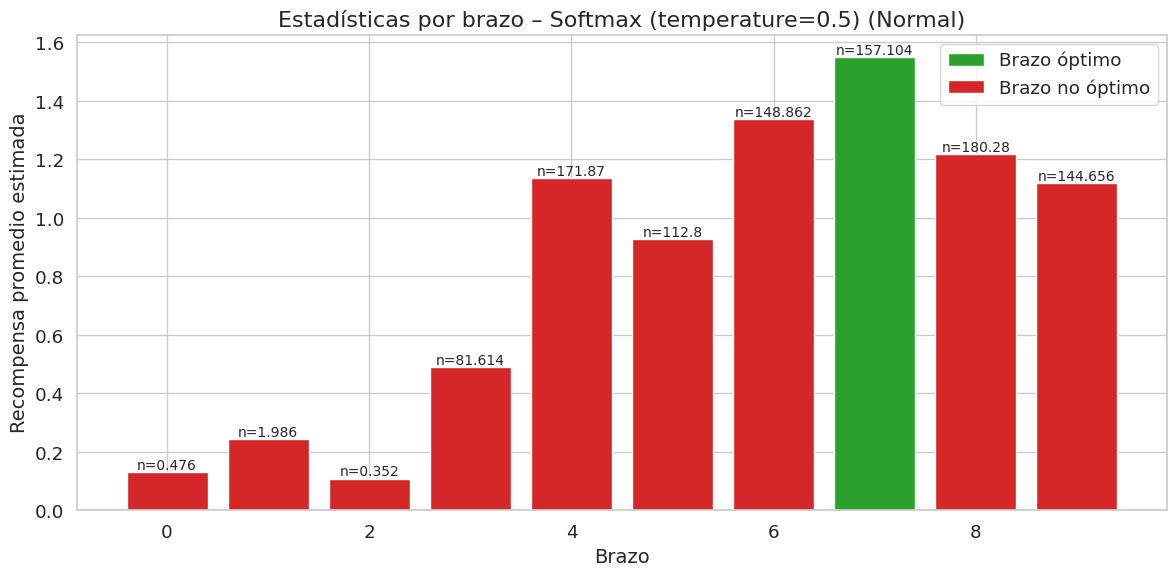

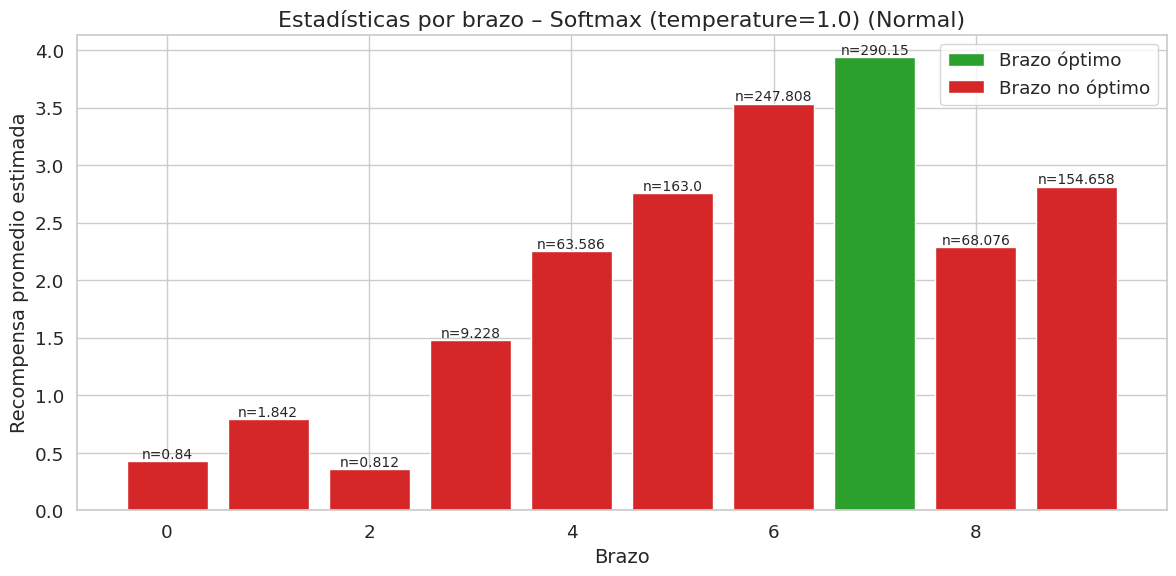

<Figure size 1400x700 with 0 Axes>

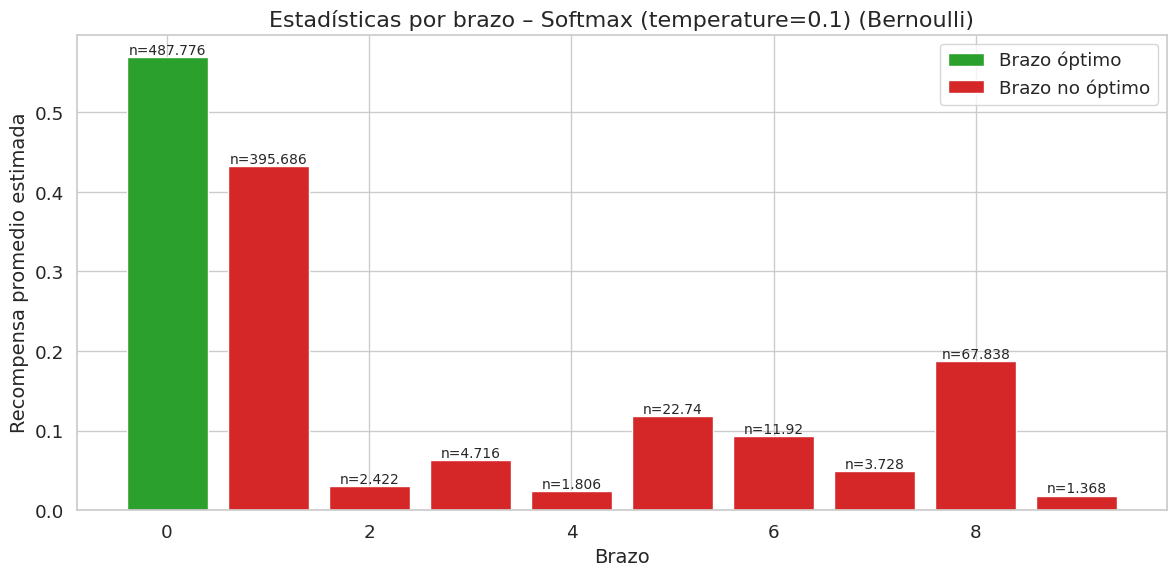

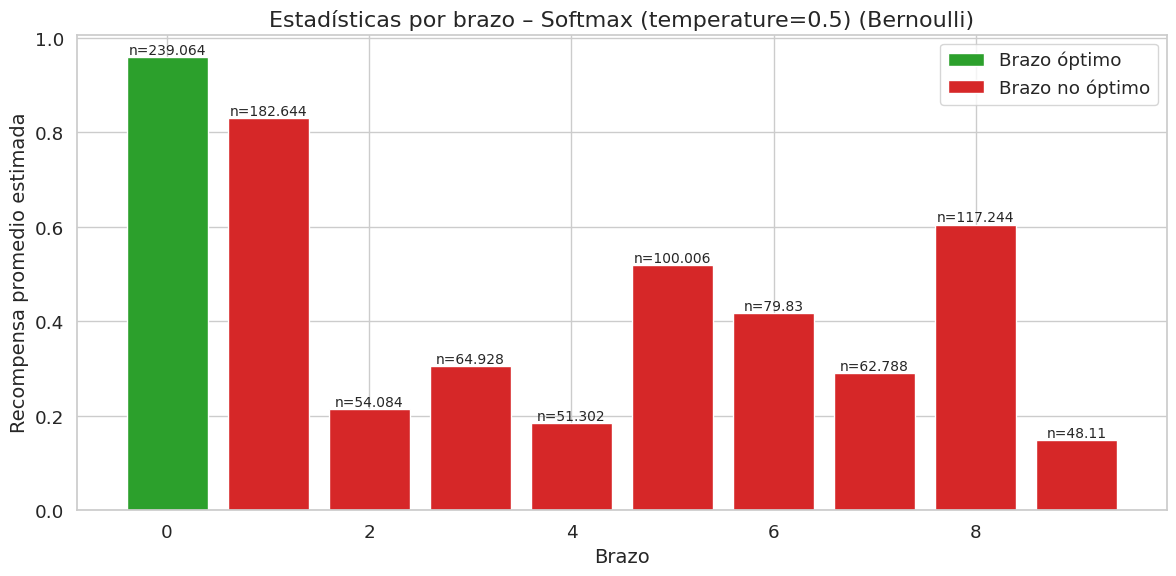

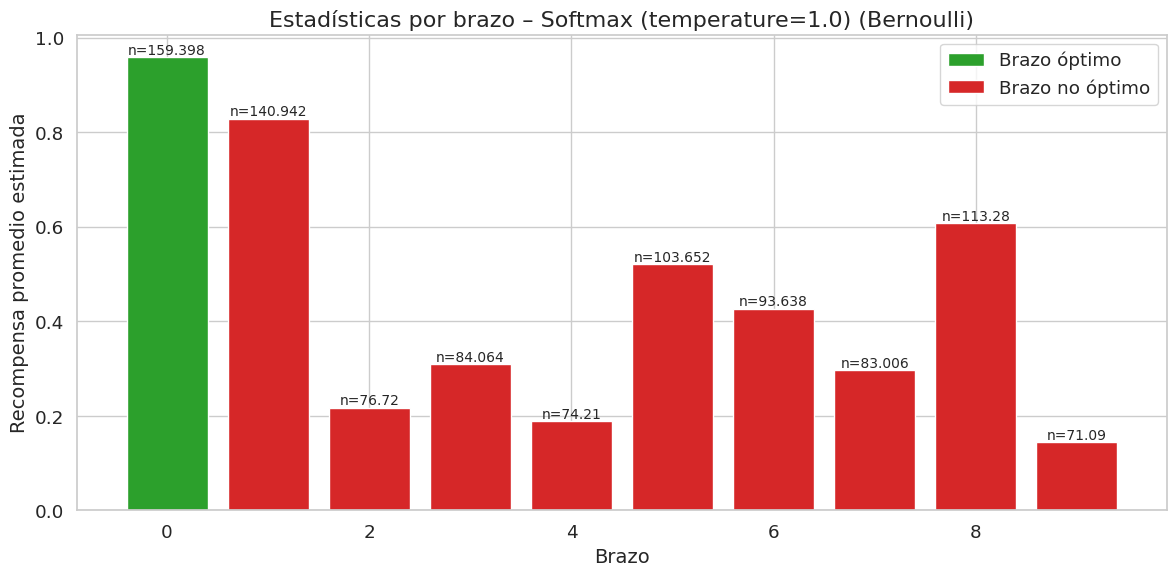

<Figure size 1400x700 with 0 Axes>

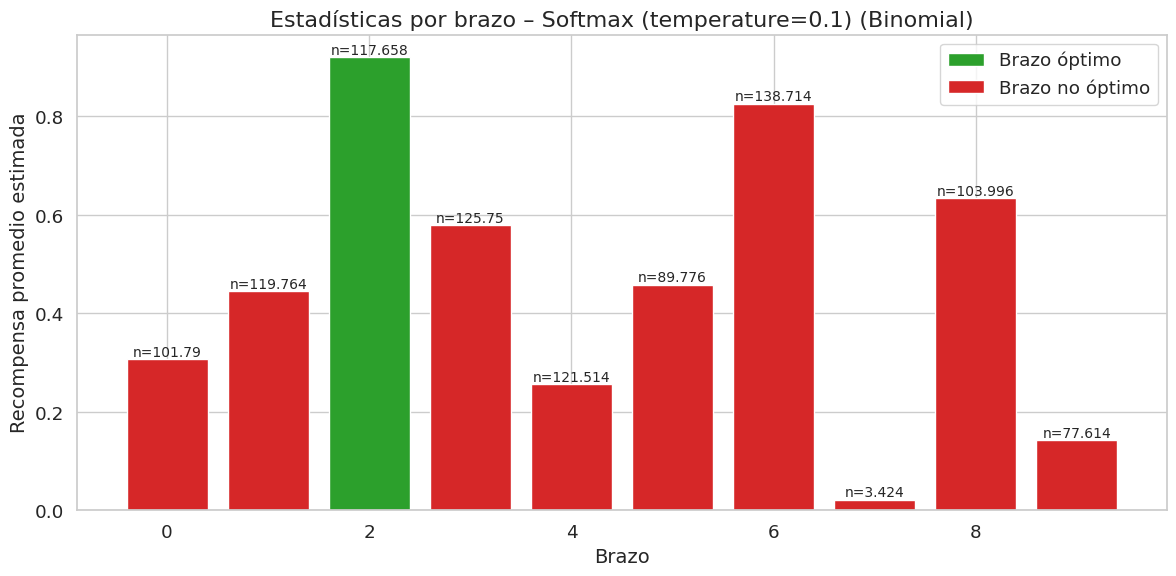

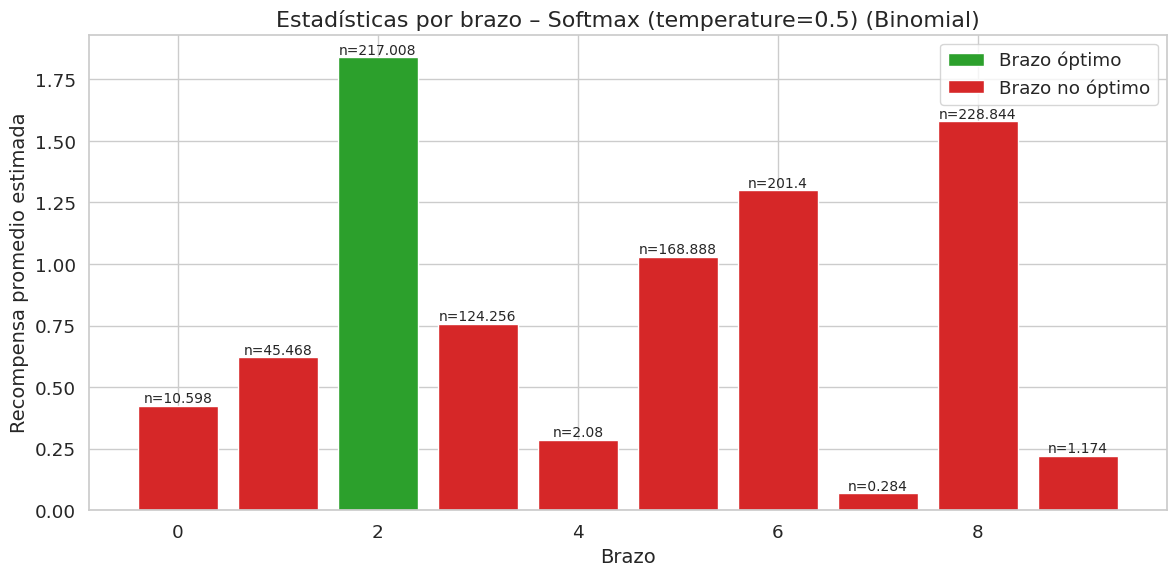

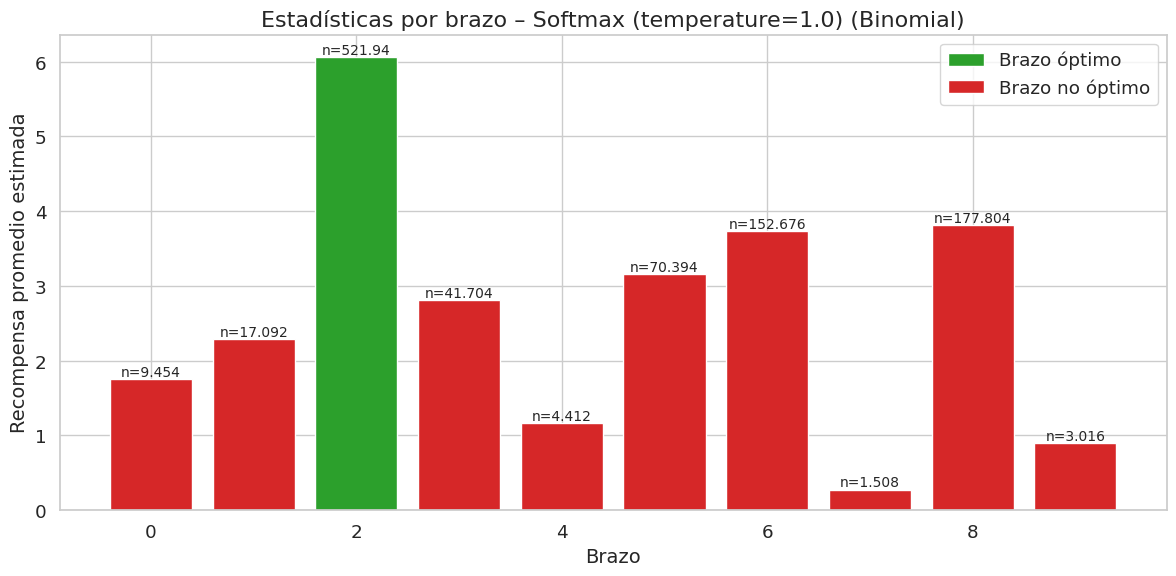

In [20]:
# Estadísticas por brazo

plot_arm_statistics(arm_stats_normal, algorithms_normal, 'Normal')
plot_arm_statistics(arm_stats_bernoulli, algorithms_bernoulli, 'Bernoulli')
plot_arm_statistics(arm_stats_binomial, algorithms_binomial, 'Binomial')


## Estadísticas por brazo

Las gráficas por brazo permiten verificar **cómo se distribuye la exploración** entre acciones y si el algoritmo concentra suficiente masa de selección en el brazo óptimo. Las etiquetas `n=` (selecciones promedio) y las barras de `avg_reward` facilitan comprobar si la política Boltzmann está alineando la frecuencia de selección con los valores estimados.

### Hallazgos principales

- **Normal**: `T=1.0` es la mejor configuración entre las evaluadas. Muestra mayor tasa de selección óptima y menor regret, lo que sugiere que `T=0.1` y `T=0.5` explotan demasiado pronto estimaciones `Q(a)` subóptimas.
- **Bernoulli**: `T=0.1` es la mejor configuración. La exploración adicional de `T=0.5` y `T=1.0` reduce el rendimiento porque mantiene selecciones no óptimas cuando el mejor brazo ya es suficientemente distinguible en términos de recompensa esperada.
- **Binomial**: `T=1.0` vuelve a ser la mejor configuración, con una diferencia notable en selección óptima y regret frente a `T=0.1` y `T=0.5`.

### Síntesis comparativa

No existe una única temperatura universalmente óptima para todas las distribuciones. En esta simulación:

- `T=1.0` funciona mejor en **Normal** y **Binomial**.
- `T=0.1` funciona mejor en **Bernoulli**.

Esto justifica que la selección de `temperature` deba formar parte del **diseño experimental** y no tratarse como un parámetro fijo independiente del tipo de bandido.


### Estadísticas por brazo

Las gráficas de **estadísticas por brazo** permiten comprobar cómo se reparte la exploración entre acciones y si la política Softmax concentra suficiente probabilidad en el brazo óptimo. Las barras muestran la recompensa promedio estimada por brazo (`avg_reward`) y las etiquetas `n=` indican el número promedio de selecciones (promediado sobre `500` ejecuciones).

#### Evidencia cuantitativa (selecciones promedio del brazo óptimo en 1000 pasos)

| Distribución | `T=0.1` | `T=0.5` | `T=1.0` | Brazo óptimo |
|---|---:|---:|---:|---:|
| Normal | 105.51 | 157.10 | **290.15** | índice `7` |
| Bernoulli | **487.78** | 239.06 | 159.40 | índice `0` |
| Binomial | 117.66 | 217.01 | **521.94** | índice `2` |

- Cuando una configuración funciona bien, se observa una **concentración clara de selecciones** en el brazo óptimo (barra verde con `n=` alto) y una estimación `avg_reward` coherente con su ventaja relativa.
- En **Normal** y **Binomial**, `T=1.0` redistribuye la exploración de forma más efectiva y termina asignando muchas más selecciones al brazo óptimo.
- En **Bernoulli**, `T=0.1` concentra rápidamente la selección en el brazo óptimo, mientras que `T=0.5` y `T=1.0` mantienen demasiada dispersión entre brazos no óptimos.

Estas gráficas son útiles como validación cualitativa de las otras métricas: permiten ver *por qué* una configuración tiene mejor recompensa y menor regret.


## Conclusiones

La temperatura `T` tiene un impacto decisivo en el rendimiento del algoritmo Softmax y su valor óptimo **depende de la distribución de recompensas** (y de la instancia concreta del bandido). En esta ejecución (`seed=42`):

- **`T=1.0`** es la mejor configuración en **Normal** y **Binomial**.
- **`T=0.1`** es la mejor configuración en **Bernoulli**.

### Consideraciones importantes

1. **No existe una temperatura universalmente óptima.**
   La selección de `temperature` debe formar parte del diseño experimental y justificarse empíricamente.

2. **Es necesario usar varias métricas de forma conjunta.**
   La recompensa promedio, la selección del brazo óptimo y el regret acumulado aportan perspectivas complementarias y, en este estudio, conducen a conclusiones consistentes.

3. **Las estadísticas por brazo mejoran la interpretabilidad.**
   Permiten verificar si el comportamiento global del algoritmo (reward/regret) se explica por una asignación razonable de selecciones a los brazos con mayor recompensa esperada.

### Limitaciones

- Los resultados dependen de una **instancia concreta** de bandido generada con semilla fija.
- Sería recomendable ampliar el estudio con más semillas, más valores de `temperature` (por ejemplo, búsqueda en rejilla), y análisis de sensibilidad respecto a `k`, `n` (en Binomial) y `\sigma` (en Normal).